In [1]:
# Kiểm tra cấu trúc thư mục bdd100k_images_100k
import os 

base_path = r"..\data\raw\bdd100k_images_100k\100k"

train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "val")
test_path = os.path.join(base_path, "test")

print(f'Train path: {os.path.exists(train_path)}')
print(f'Val path: {os.path.exists(val_path)}')
print(f'Test path: {os.path.exists(test_path)}')

print(f'Nội dung thư mục base_path: {os.listdir(base_path)} ')


Train path: True
Val path: True
Test path: True
Nội dung thư mục base_path: ['test', 'train', 'val'] 


Số lượng ảnh trong thư mục train: 70000
Số lượng ảnh trong thư mục val: 10000
Số lượng ảnh trong thư mục test: 20000
Sample ảnh trong thư mục train:


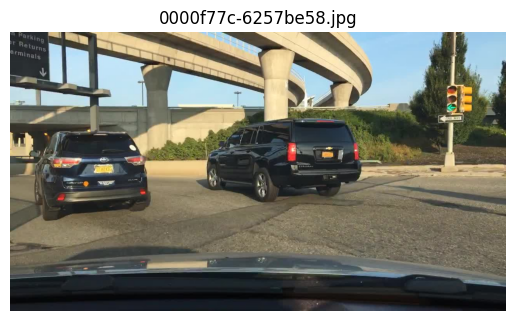

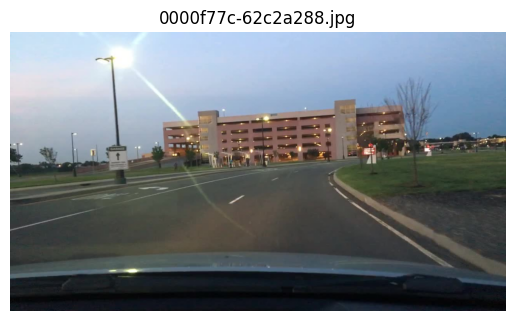

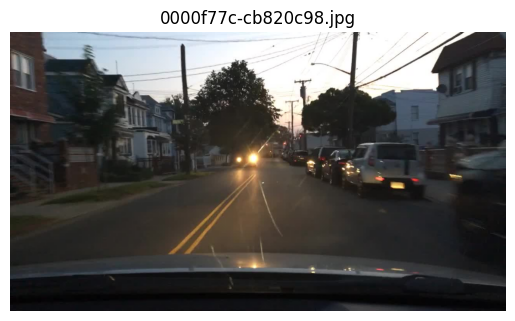

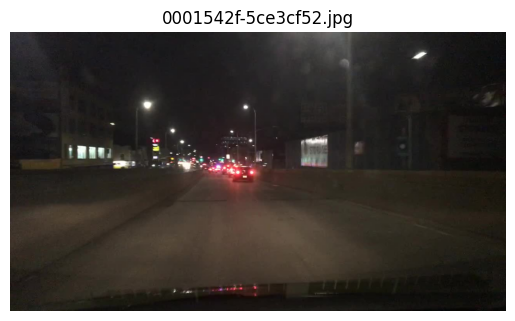

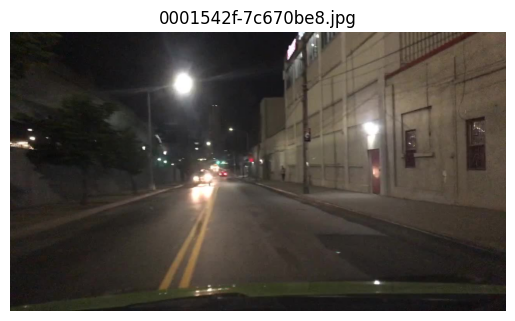

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Kiểm tra số lượng ảnh trong tập dữ liệu raw
num_train_images = len(os.listdir(train_path))
num_val_images = len(os.listdir(val_path))
num_test_images = len(os.listdir(test_path))

print(f'Số lượng ảnh trong thư mục train: {num_train_images}')
print(f'Số lượng ảnh trong thư mục val: {num_val_images}')
print(f'Số lượng ảnh trong thư mục test: {num_test_images}')

# Hiển thị một số ảnh mẫu từ thư mục train
print(f'Sample ảnh trong thư mục train:')
sample_images = os.listdir(train_path)[:5]
for img_name in sample_images:
    img_path = os.path.join(train_path, img_name)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()

In [3]:
import json
import os

# Kiểm tra cấu trúc file labels trong thư mục bdd100k_labels
sample_json = os.path.join(r"..\data\raw\bdd100k_labels\100k", "train", "0a0a0b1a-7c39d841.json")

with open(sample_json, "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))
print(data)

<class 'dict'>
{'name': '0a0a0b1a-7c39d841', 'frames': [{'timestamp': 10000, 'objects': [{'category': 'car', 'id': 0, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 555.647397, 'y1': 304.228432, 'x2': 574.015906, 'y2': 316.474104}}, {'category': 'car', 'id': 1, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 554.116689, 'y1': 318.004813, 'x2': 567.89307, 'y2': 328.719775}}, {'category': 'car', 'id': 2, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 523.502507, 'y1': 311.881977, 'x2': 544.932435, 'y2': 327.189068}}, {'category': 'car', 'id': 3, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 492.888326, 'y1': 311.881977, 'x2': 526.563926, 'y2': 337.904031}}, {'category': 'truck', 'id': 4, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1'

In [5]:
import json
import os
from tqdm import tqdm 
from collections import defaultdict

base_path_labels = r"..\data\raw\bdd100k_labels\100k"
phases = ["train"]

all_labels = {}
label_counter = defaultdict(int)

for phase in phases:
    folder_path = os.path.join(base_path_labels, phase)
    data_lists = []

    if os.path.exists(folder_path):
        json_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]
        count = 0
        
        for filename in tqdm(json_files, desc=f"Loading {phase} JSON files"):
            file_path = os.path.join(folder_path, filename)
            
            try:
                with open(file_path, "r", encoding="utf-8") as file:
                    data = json.load(file)
                    data_lists.append(data)
                    
                    # Duyệt qua các đối tượng trong annotation và đếm số lượng mỗi loại
                    if "frames" in data:
                        for frame in data["frames"]:
                            if "objects" in frame:
                                for obj in frame["objects"]:
                                    label_counter[obj["category"]] += 1
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
                
        all_labels[phase] = data_lists 
        print(f"-> Loaded {count} JSON files from {phase} phase.")
    else:
        print(f"Folder {folder_path} does not exist.")
        all_labels[phase] = data_lists

# Tổng hợp số lượng mỗi loại đối tượng trong tập train
print("\n==== TỔNG KẾT DATASET ====")
for phase in phases:
    print(f"- {phase}: {len(all_labels[phase])} files).")
    
print("\n==== DANH SÁCH LABEL & SỐ LƯỢNG ====")
print(f"Tổng số loại label: {len(label_counter)}\n")

for label, count in sorted(label_counter.items(), key=lambda x: x[1], reverse=True):
    print(f"{label:25s}: {count}")


Loading train JSON files: 100%|██████████| 70000/70000 [11:14<00:00, 103.71it/s]

-> Loaded 0 JSON files from train phase.

==== TỔNG KẾT DATASET ====
- train: 70000 files).

==== DANH SÁCH LABEL & SỐ LƯỢNG ====
Tổng số loại label: 21

car                      : 714121
lane/single white        : 247108
traffic sign             : 239961
traffic light            : 186301
lane/road curb           : 109868
lane/crosswalk           : 108284
person                   : 91435
area/drivable            : 64050
area/alternative         : 61799
lane/double yellow       : 37519
truck                    : 30012
lane/single yellow       : 20220
bus                      : 11688
bike                     : 7227
lane/double white        : 5674
rider                    : 4522
motor                    : 3002
lane/single other        : 249
train                    : 136
lane/double other        : 26
area/unknown             : 2
